# A6: Naive RAG vs Contextual Retrieval

**by Dechathon Niamsa-ard [st126235]**

### Import Necessary Libraries

In [1]:
import os
import json
import re
import asyncio
import time
from pathlib import Path

from dotenv import load_dotenv
import fitz                           # PyMuPDF
import nest_asyncio
import numpy as np
import pandas as pd
from tqdm import tqdm
from openai import OpenAI, AsyncOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter   # langchain >=0.3
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

# Allow asyncio.run() inside Jupyter, which already has a running event loop
nest_asyncio.apply()

# Load OPENAI_API_KEY from .env
load_dotenv()

# OpenAI clients
client       = OpenAI()
async_client = AsyncOpenAI()

# Directory setup
DATA_DIR   = Path("data")
INDEX_DIR  = Path("index")
ANSWER_DIR = Path("answer")
ASSETS_DIR = Path("assets")
INDEX_DIR.mkdir(exist_ok=True)
ANSWER_DIR.mkdir(exist_ok=True)
ASSETS_DIR.mkdir(exist_ok=True)

# Model identifiers
EMBED_MODEL   = "text-embedding-3-small"
GEN_MODEL     = "gpt-4o-mini"
CHAPTER_TITLE = "Chapter 5: Vector Semantics and Embeddings (Speech and Language Processing, 3rd ed.)"

print("All libraries loaded successfully.")
print(f"  Embedding model : {EMBED_MODEL}")
print(f"  Generator model : {GEN_MODEL}")
print(f"  Chapter         : {CHAPTER_TITLE}")

All libraries loaded successfully.
  Embedding model : text-embedding-3-small
  Generator model : gpt-4o-mini
  Chapter         : Chapter 5: Vector Semantics and Embeddings (Speech and Language Processing, 3rd ed.)


## Task 1. Source Discovery & Data Preparation

1) Select Your Chapter: Identify the last digit of your student ID (e.g., if your ID is st124859, the last digit is 9). You must extract the content of the corresponding chapter from the course textbook (https://web.stanford.edu/~jurafsky/slp3/) or a relevant machine learning book.
   - If the last digit is 1, use Chapter 11.
   - If the last digit is 0, use Chapter 10.
   - Example: ID ending in 2 → Chapter 2; ID ending in 9 → Chapter 9.
2) Document Processing: Load and process the text from your assigned chapter. Clean the data as necessary for RAG implementation. (1 point)
3) QA Pair Generation: Create a dataset of at least 20 Question-Answer pairs based strictly on the content of your assigned chapter.
   - Collaboration Note: You may collaborate with other students who have the same assigned chapter to generate these questions, but the implementation must be your own. (1 point)

### Implementation Notes

My student ID ends in **5**, so I use **Chapter 5: Vector Semantics and Embeddings** from the Stanford Speech and Language Processing (SLP3) textbook. The chapter PDF is saved locally at `data/5.pdf` (sourced from https://web.stanford.edu/~jurafsky/slp3/5.pdf).

**Document loading:** I use [PyMuPDF](https://pymupdf.readthedocs.io/) (`fitz`) to extract raw text from each page of the PDF. PyMuPDF provides direct access to the text layer without OCR, keeping the extracted content clean and faithful to the original.

**Cleaning strategy:** Academic PDFs often contain noise — standalone page numbers on their own lines, repeated header/footer text, and excessive whitespace. I strip standalone numeric lines (page numbers), filter out very short lines that are likely headers or artefacts, and collapse triple-or-more newlines into double newlines to normalise paragraph boundaries.

**Chunking:** I use LangChain's `RecursiveCharacterTextSplitter` with `chunk_size=800` characters and `chunk_overlap=100`. The recursive splitter first tries to break on paragraph boundaries (`\n\n`), then on single newlines, then on sentence endings (`. `), which preserves semantic coherence within each chunk. The 100-character overlap ensures that context is not lost at chunk boundaries.

In [2]:
def load_and_clean_pdf(path: Path) -> str:
    """Extract and clean text from a PDF using PyMuPDF."""
    doc = fitz.open(str(path))
    pages = []
    for page in doc:
        text = page.get_text("text")
        # Remove standalone page-number lines (digits only)
        text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE)
        # Drop very short lines (headers, footers, artefacts ≤ 2 chars)
        lines = [ln for ln in text.split('\n') if len(ln.strip()) > 2]
        pages.append('\n'.join(lines))
    raw = '\n\n'.join(pages)
    # Collapse excess blank lines and horizontal whitespace
    raw = re.sub(r'\n{3,}', '\n\n', raw)
    raw = re.sub(r'[ \t]{2,}', ' ', raw)
    return raw.strip()

chapter_text = load_and_clean_pdf(DATA_DIR / "5.pdf")
print(f"Extracted {len(chapter_text):,} characters from Chapter 5.")
print(f"\n--- First 800 characters ---")
print(chapter_text[:800])

Extracted 83,393 characters from Chapter 5.

--- First 800 characters ---
Speech and Language Processing.
Daniel Jurafsky & James H. Martin.
Copyright © 2026.
All
rights reserved.
Draft of January 6, 2026.
CHAPTER
Embeddings
荃者所以在鱼，得鱼而忘荃Nets are for ﬁsh;
Once you get the ﬁsh, you can forget the net.
言者所以在意，得意而忘言Words are for meaning;
Once you get the meaning, you can forget the words
庄子(Zhuangzi), Chapter 26
The asphalt that Los Angeles is famous for occurs mainly on its freeways. But
in the middle of the city is another patch of asphalt, the La Brea tar pits, and this
asphalt preserves millions of fossil bones from the last of the Ice Ages of the Pleis-
tocene Epoch. One of these fossils is the Smilodon, or saber-toothed tiger, instantly
recognizable by its long canines. Five million years ago or so, a completely different
saber-tooth tiger called Thylacosmilus


In [3]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " "],
    length_function=len,
)
chunks = splitter.split_text(chapter_text)

print(f"Total chunks produced : {len(chunks)}")
print(f"Average chunk size    : {sum(len(c) for c in chunks) / len(chunks):.0f} chars")
print(f"Min / Max chunk size  : {min(len(c) for c in chunks)} / {max(len(c) for c in chunks)} chars")

for i, c in enumerate(chunks[:3]):
    print(f"\n{'='*60}")
    print(f"Chunk {i}  (len={len(c)})")
    print('='*60)
    print(c[:400])

Total chunks produced : 130
Average chunk size    : 701 chars
Min / Max chunk size  : 177 / 799 chars

Chunk 0  (len=761)
Speech and Language Processing.
Daniel Jurafsky & James H. Martin.
Copyright © 2026.
All
rights reserved.
Draft of January 6, 2026.
CHAPTER
Embeddings
荃者所以在鱼，得鱼而忘荃Nets are for ﬁsh;
Once you get the ﬁsh, you can forget the net.
言者所以在意，得意而忘言Words are for meaning;
Once you get the meaning, you can forget the words
庄子(Zhuangzi), Chapter 26
The asphalt that Los Angeles is famous for occurs mainly on it

Chunk 1  (len=759)
recognizable by its long canines. Five million years ago or so, a completely different
saber-tooth tiger called Thylacosmilus lived
in Argentina and other parts of South Amer-
ica. Thylacosmilus was a marsupial whereas
Smilodon was a placental mammal, but Thy-
lacosmilus had the same long upper canines
and, like Smilodon, had a protective bone
ﬂange on the lower jaw.
The similarity of
these two ma

Chunk 2  (len=756)
of organism: the word. Words that oc

### QA Pair Dataset

To evaluate both RAG pipelines meaningfully I use a set of 20 ground-truth question–answer pairs grounded strictly in Chapter 5. The pairs were manually curated to cover a representative range of topics from the chapter: definitions (distributional hypothesis, vector semantics, lemma vs. wordform), mathematical concepts (cosine similarity, dot product, co-occurrence matrix), algorithms (skip-gram, negative sampling, fasttext), analysis (sparse vs. dense vectors, first-order vs. second-order co-occurrence, analogy tasks), and applied concerns (bias/allocational harm, evaluation datasets).

The pairs are hardcoded as `CURATED_QA_PAIRS` in the cell below and cached to `answer/qa_pairs_raw.json` on first run. Subsequent notebook executions load from cache without re-writing.

In [4]:
QA_CACHE = ANSWER_DIR / "qa_pairs_raw.json"

# Manually curated 20 QA pairs based strictly on Chapter 5: Vector Semantics and Embeddings
CURATED_QA_PAIRS = [
    {
        "question": "What is the distributional hypothesis?",
        "ground_truth_answer": "The distributional hypothesis is the link between the similarity in how words are distributed in text and the similarity in what they mean. It posits that words occurring in similar contexts tend to have similar meanings."
    },
    {
        "question": "How is vector semantics defined in the context of NLP?",
        "ground_truth_answer": "Vector semantics is the linguistic field that studies embeddings, which are vector representations of the meaning of words learned directly from word distributions in texts."
    },
    {
        "question": "What is the difference between a lemma and a wordform?",
        "ground_truth_answer": "A lemma, or citation form, is the base form of a word, such as 'mouse' or 'sing'. A wordform is the specific inflected form of that word, such as 'mice', 'sung', or 'carpets'."
    },
    {
        "question": "According to the principle of contrast, do true, identical synonyms exist?",
        "ground_truth_answer": "Probably no two words are absolutely identical in meaning. The principle of contrast states that a difference in linguistic form is always associated with some difference in meaning."
    },
    {
        "question": "How does 'word relatedness' differ from 'word similarity'?",
        "ground_truth_answer": "Words can be related without being similar; for example, 'coffee' and 'cup' share practically no features and are not similar, but they are related eventively because they co-participate in the everyday event of drinking."
    },
    {
        "question": "What three dimensions did Osgood et al. (1957) use to represent the affective meaning of words?",
        "ground_truth_answer": "They used valence (the pleasantness of the stimulus), arousal (the intensity of emotion provoked), and dominance (the degree of control exerted by the stimulus)."
    },
    {
        "question": "What does a cell in a word-context co-occurrence matrix represent?",
        "ground_truth_answer": "Each cell records the number of times the target word (represented by the row) and the context word (represented by the column) co-occur nearby in a training corpus."
    },
    {
        "question": "Why is the raw dot product a problematic metric for measuring word similarity?",
        "ground_truth_answer": "The raw dot product is problematic because it favors long vectors. Frequent words tend to co-occur with more words, resulting in longer vectors and higher raw dot products simply due to their frequency."
    },
    {
        "question": "How does cosine similarity correct the issue of vector length?",
        "ground_truth_answer": "It modifies the dot product to normalize for vector length by dividing the dot product by the lengths of each of the two vectors."
    },
    {
        "question": "What are the primary structural differences between sparse vectors and dense embeddings?",
        "ground_truth_answer": "Sparse vectors are very long, with dimensionality matching the vocabulary size, and mostly contain zeros. Dense embeddings are short (ranging from 50 to 1000 dimensions) and contain real-valued numbers that can be negative."
    },
    {
        "question": "Why might dense vectors perform better than sparse vectors in NLP applications?",
        "ground_truth_answer": "Representing words as shorter dense vectors requires classifiers to learn far fewer weights, which possibly helps with generalization and avoiding overfitting. Dense vectors may also do a better job of capturing synonymy."
    },
    {
        "question": "What is the core intuition behind the skip-gram algorithm?",
        "ground_truth_answer": "The intuition is to train a classifier on a binary prediction task—asking if a word is likely to show up near a target word—and then take the learned classifier weights to use as the word embeddings."
    },
    {
        "question": "How does skip-gram with negative sampling (SGNS) generate negative examples?",
        "ground_truth_answer": "For each positive training instance, it creates negative samples by pairing the target word with a random 'noise word' from the lexicon, constrained so it is not the target word."
    },
    {
        "question": "Why is the unigram probability weighting parameter alpha typically set to 0.75 in negative sampling?",
        "ground_truth_answer": "Setting alpha = 0.75 gives better performance because it slightly increases the probability of selecting rare words as noise words."
    },
    {
        "question": "How does the fasttext algorithm handle unknown words?",
        "ground_truth_answer": "Fasttext uses subword models that represent each word as a bag of constituent character n-grams, meaning unknown words can be represented by the sum of the embeddings of their constituent n-grams."
    },
    {
        "question": "What is a common method used to visualize high-dimensional word embeddings in two dimensions?",
        "ground_truth_answer": "A common method is to project the dimensions down into 2 dimensions using a projection method called t-SNE."
    },
    {
        "question": "What is the difference between first-order and second-order co-occurrence?",
        "ground_truth_answer": "Two words have first-order co-occurrence (syntagmatic association) if they are typically nearby each other, whereas they have second-order co-occurrence (paradigmatic association) if they simply have similar neighbors."
    },
    {
        "question": "How does the parallelogram model solve simple analogy problems like 'apple is to tree as grape is to what?'",
        "ground_truth_answer": "It subtracts the vector for 'apple' from 'tree' and adds the vector for 'grape'; the nearest word to that resulting point is returned as the answer."
    },
    {
        "question": "How can embeddings lead to 'allocational harm' in real-world systems?",
        "ground_truth_answer": "Embeddings reproduce and amplify implicit biases and stereotypes latent in text. This can cause allocational harm if an algorithm uses these biased embeddings to unfairly allocate resources, such as incorrectly downweighting women's names when searching for programmers."
    },
    {
        "question": "What are WordSim-353 and SimLex-999 used for?",
        "ground_truth_answer": "They are intrinsic evaluation datasets used to test vector models by computing the correlation between an algorithm's word similarity scores and human-assigned ratings."
    },
]

if QA_CACHE.exists():
    with open(QA_CACHE, encoding="utf-8") as f:
        qa_pairs = json.load(f)
    print(f"Loaded {len(qa_pairs)} QA pairs from cache.")
else:
    qa_pairs = CURATED_QA_PAIRS
    with open(QA_CACHE, "w", encoding="utf-8") as f:
        json.dump(qa_pairs, f, indent=2, ensure_ascii=False)
    print(f"Saved {len(qa_pairs)} curated QA pairs to cache.")

# Display as a scrollable table
pd.set_option("display.max_colwidth", 120)
pd.DataFrame(qa_pairs)[["question", "ground_truth_answer"]]

Saved 20 curated QA pairs to cache.


,question,ground_truth_answer
0,What is the distributional hypothesis?,The distributional hypothesis is the link between the similarity in how words are distributed in text and the simila...
1,How is vector semantics defined in the context of NLP?,"Vector semantics is the linguistic field that studies embeddings, which are vector representations of the meaning of..."
2,What is the difference between a lemma and a wordform?,"A lemma, or citation form, is the base form of a word, such as 'mouse' or 'sing'. A wordform is the specific inflect..."
3,"According to the principle of contrast, do true, identical synonyms exist?",Probably no two words are absolutely identical in meaning. The principle of contrast states that a difference in lin...
4,How does 'word relatedness' differ from 'word similarity'?,"Words can be related without being similar; for example, 'coffee' and 'cup' share practically no features and are no..."
5,What three dimensions did Osgood et al. (1957) use to represent the affective meaning of words?,"They used valence (the pleasantness of the stimulus), arousal (the intensity of emotion provoked), and dominance (th..."
6,What does a cell in a word-context co-occurrence matrix represent?,Each cell records the number of times the target word (represented by the row) and the context word (represented by ...
7,Why is the raw dot product a problematic metric for measuring word similarity?,"The raw dot product is problematic because it favors long vectors. Frequent words tend to co-occur with more words, ..."
8,How does cosine similarity correct the issue of vector length?,It modifies the dot product to normalize for vector length by dividing the dot product by the lengths of each of the...
9,What are the primary structural differences between sparse vectors and dense embeddings?,"Sparse vectors are very long, with dimensionality matching the vocabulary size, and mostly contain zeros. Dense embe..."


## Task 2. Technique Comparison: Naive RAG vs. Contextual Retrieval

1) Implement Naive RAG: Build a standard RAG pipeline using a basic chunking strategy and a standard vector retriever.
2) Implement Contextual Retrieval: Implement the Contextual Retrieval technique (https://www.anthropic.com/engineering/contextual-retrieval) where context is prepended to chunks to improve retrieval quality.

**Hint Code for Contextual Enrichment:**
```python
async def enrich_chunk(chunk: str, document: str, title: str) -> str:
    """Add contextual prefix using LLM"""
    prompt = f"""
    Title: {title}
    {document[:4000]}
    {chunk}
    
    Provide brief context (1-2 sentences) explaining what this chunk discusses
    in relation to the full document.
    Format: "This chunk from [title] discusses [explanation]."
    """
    
    response = await client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=150
    )
    
    context = response.choices[0].message.content.strip()
    
    # Embed the contextualized version
    return f"{context}\n\n{chunk}"
```

**Example Before and After:**
- **BEFORE:** "Revenue grew 40% to $314M with improved margins."
- **AFTER:** "This chunk from ACME Corp's Q2 2024 SEC filing discusses quarterly financial performance compared to Q1 2024. Revenue grew 40% to $314M with improved margins."

3) Evaluation: Run your 20 QA pairs through both pipelines.
4) Analysis: Calculate the ROUGE scores (ROUGE-1, ROUGE-2, ROUGE-L) for the generated answers against the ground truth. Present your findings in the table format below. Discuss the results. (2 points)

**Evaluation Table**
| Method | ROUGE-1 | ROUGE-2 | ROUGE-L |
| :--- | :--- | :--- | :--- |
| Naive RAG | 0.XX | 0.XX | 0.XX |
| Contextual Retrieval | 0.XX | 0.XX | 0.XX |

**Note:** RAG utilizes two models: a retriever model and a generator model. Ensure you clearly state which models you are using for each component.


### Models Used

| Component | Model | Role |
|-----------|-------|------|
| **Embedder** | `text-embedding-3-small` | Converts text chunks and queries to dense vectors |
| **Generator** | `gpt-4o-mini` | Generates natural-language answers from retrieved context |
| **Context Enrichment LLM** | `gpt-4o-mini` | Prepends a 1–2 sentence contextual prefix to each chunk |

---

### Pipeline Architecture

```
                   ┌─────────────────────────────────────────────┐
                   │           DOCUMENT PROCESSING               │
                   │  PDF → clean text → RecursiveCharTextSplit  │
                   └──────────────┬──────────────────────────────┘
                                  │ raw chunks
              ┌───────────────────┴──────────────────────┐
              │                                          │
       NAIVE RAG                           CONTEXTUAL RETRIEVAL
       ─────────                           ────────────────────
  raw chunks                          raw chunks
  → embed(text-embedding-3-small)     → gpt-4o-mini(context prefix)
  → FAISS index                       → enriched chunks
        │                             → embed(text-embedding-3-small)
        │                             → FAISS index
        └────────── query → retrieve k chunks ──────────┘
                            │
                    gpt-4o-mini(generator)
                            │
                         answer
```

I use `text-embedding-3-small` for both pipelines because it is OpenAI's most cost-efficient dense embedding model while still achieving strong retrieval quality. The only difference between the two pipelines is whether the chunks carry an LLM-generated contextual prefix before being embedded.

In [5]:
# Shared embedding model instance (used by both pipelines)
embeddings = OpenAIEmbeddings(model=EMBED_MODEL)

def generate_answer(question: str, context_chunks: list[str]) -> str:
    """Generate a concise answer given a question and a list of context chunks."""
    context = "\n\n---\n\n".join(context_chunks)
    prompt = (
        "Answer the following question using ONLY the provided context.\n"
        "Be concise (3–5 sentences). If the context does not contain enough information, say so.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )
    resp = client.chat.completions.create(
        model=GEN_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=300,
    )
    return resp.choices[0].message.content.strip()

print("Shared embedding model and generator helper initialised.")

Shared embedding model and generator helper initialised.


#### 2.1 Naive RAG — Build Index

In the Naive RAG pipeline, I embed the raw, unmodified text chunks directly using `text-embedding-3-small` and store them in a FAISS flat index. At query time, the top-`k` most similar chunks are retrieved by cosine similarity and passed verbatim to `gpt-4o-mini` as context.

The index is persisted to `index/naive_faiss/` after the first build so that re-running the notebook does not incur redundant embedding API calls.

In [6]:
NAIVE_INDEX = INDEX_DIR / "naive_faiss"

if NAIVE_INDEX.exists():
    naive_db = FAISS.load_local(
        str(NAIVE_INDEX), embeddings, allow_dangerous_deserialization=True
    )
    print(f"Loaded Naive FAISS index from {NAIVE_INDEX}  ({len(chunks)} chunks).")
else:
    print("Building Naive FAISS index ...")
    naive_db = FAISS.from_texts(chunks, embedding=embeddings)
    naive_db.save_local(str(NAIVE_INDEX))
    print(f"Index built and saved to {NAIVE_INDEX}  ({len(chunks)} chunks).")

def naive_rag(question: str, k: int = 4) -> tuple[str, list[str]]:
    """Retrieve top-k raw chunks and generate an answer."""
    docs = naive_db.similarity_search(question, k=k)
    ctx  = [d.page_content for d in docs]
    return generate_answer(question, ctx), ctx

Building Naive FAISS index ...
Index built and saved to index\naive_faiss  (130 chunks).


#### 2.2 Contextual Retrieval — Enrich Chunks then Build Index

Contextual Retrieval, introduced by Anthropic, prepends a short, document-aware description to every chunk *before* embedding it. This gives the embedding model richer signal about where in the document each chunk belongs, leading to more accurate similarity search at query time.

I implement the enrichment step as an **async batch process**: all chunks are enriched concurrently (up to 8 at a time via a semaphore, to respect API rate limits). The enriched chunks are cached to `index/contextual_chunks.json` after the first run, and the resulting FAISS index is saved to `index/contextual_faiss/`.

**Example — before and after enrichment:**

```
BEFORE: "Cosine similarity measures the angle between two vectors and is defined as
         cos(v, w) = v·w / (|v||w|)."

AFTER:  "This chunk from Chapter 5: Vector Semantics and Embeddings (SLP3) discusses
         the cosine similarity metric used to measure semantic similarity between word
         vectors in the vector space model.

         Cosine similarity measures the angle between two vectors and is defined as
         cos(v, w) = v·w / (|v||w|)."
```

In [7]:
async def enrich_chunk(chunk: str) -> str:
    """Prepend a contextual description to a single chunk using gpt-4o-mini (async)."""
    prompt = (
        f"Title: {CHAPTER_TITLE}\n\n"
        f"Document excerpt (first 4 000 chars for context):\n{chapter_text[:4000]}\n\n"
        f"Chunk to contextualize:\n{chunk}\n\n"
        "Provide 1-2 sentences explaining what this chunk discusses in relation to "
        "the full document. Start your response with: "
        f'"This chunk from {CHAPTER_TITLE} discusses"'
    )
    resp = await async_client.chat.completions.create(
        model=GEN_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=150,
    )
    prefix = resp.choices[0].message.content.strip()
    return f"{prefix}\n\n{chunk}"

async def enrich_all(chunks: list[str]) -> list[str]:
    """Enrich all chunks concurrently with a concurrency cap of 8 requests."""
    sem = asyncio.Semaphore(8)
    async def bounded(c: str) -> str:
        async with sem:
            return await enrich_chunk(c)
    return await asyncio.gather(*[bounded(c) for c in chunks])

In [8]:
CTX_CHUNKS_CACHE = INDEX_DIR / "contextual_chunks.json"

if CTX_CHUNKS_CACHE.exists():
    with open(CTX_CHUNKS_CACHE, encoding="utf-8") as f:
        enriched_chunks = json.load(f)
    print(f"Loaded {len(enriched_chunks)} enriched chunks from cache.")
else:
    print(f"Enriching {len(chunks)} chunks with LLM context ...")
    print("(First run — this may take 2–4 minutes)")
    enriched_chunks = asyncio.run(enrich_all(chunks))
    with open(CTX_CHUNKS_CACHE, "w", encoding="utf-8") as f:
        json.dump(enriched_chunks, f, indent=2, ensure_ascii=False)
    print(f"Enriched and cached {len(enriched_chunks)} chunks.")

# Show a before/after comparison for chunk index 5
print("\n" + "="*70)
print("BEFORE (raw chunk):")
print("="*70)
print(chunks[5][:300])
print("\n" + "="*70)
print("AFTER (enriched chunk with contextual prefix):")
print("="*70)
print(enriched_chunks[5][:500])

Enriching 130 chunks with LLM context ...
(First run — this may take 2–4 minutes)
Enriched and cached 130 chunks.

BEFORE (raw chunk):
CHAPTER 5
EMBEDDINGS
5.1
Lexical Semantics
Let’s begin by introducing some basic principles of word meaning. How should
we represent the meaning of a word? In the n-gram models of Chapter 3, and in
classical NLP applications, our only representation of a word is as a string of letters,
or an index i

AFTER (enriched chunk with contextual prefix):
This chunk from Chapter 5: Vector Semantics and Embeddings (Speech and Language Processing, 3rd ed.) discusses the fundamental principles of word meaning representation in natural language processing (NLP). It critiques traditional methods, such as representing words merely as strings of letters or capitalized forms, and sets the stage for introducing more sophisticated models, like embeddings, that capture the semantic relationships between words based on their usage in context.

CHAPTER 5
EMBE


In [9]:
CTX_INDEX = INDEX_DIR / "contextual_faiss"

if CTX_INDEX.exists():
    ctx_db = FAISS.load_local(
        str(CTX_INDEX), embeddings, allow_dangerous_deserialization=True
    )
    print(f"Loaded Contextual FAISS index from {CTX_INDEX}.")
else:
    print("Building Contextual FAISS index ...")
    ctx_db = FAISS.from_texts(enriched_chunks, embedding=embeddings)
    ctx_db.save_local(str(CTX_INDEX))
    print(f"Contextual FAISS index built and saved to {CTX_INDEX}.")

def contextual_rag(question: str, k: int = 4) -> tuple[str, list[str]]:
    """Retrieve top-k enriched chunks and generate an answer."""
    docs = ctx_db.similarity_search(question, k=k)
    ctx  = [d.page_content for d in docs]
    return generate_answer(question, ctx), ctx

Building Contextual FAISS index ...
Contextual FAISS index built and saved to index\contextual_faiss.


#### 2.3 Evaluation — Run 20 QA Pairs Through Both Pipelines

With both indices built, I now run all 20 question–answer pairs through each pipeline. For every question, both `naive_rag()` and `contextual_rag()` are called, the generated answers and retrieved source chunks are recorded, and the full results are cached to `index/evaluation_results.json` to avoid re-running the API calls on subsequent executions.

In [10]:
RESULTS_CACHE = INDEX_DIR / "evaluation_results.json"

if RESULTS_CACHE.exists():
    with open(RESULTS_CACHE, encoding="utf-8") as f:
        results = json.load(f)
    print(f"Loaded {len(results)} cached evaluation results.")
else:
    print(f"Running {len(qa_pairs)} QA pairs through both pipelines ...")
    results = []
    for pair in tqdm(qa_pairs, desc="Evaluating"):
        q  = pair["question"]
        gt = pair["ground_truth_answer"]
        naive_ans, naive_src = naive_rag(q)
        ctx_ans,   ctx_src   = contextual_rag(q)
        results.append({
            "question":                    q,
            "ground_truth_answer":         gt,
            "naive_rag_answer":            naive_ans,
            "contextual_retrieval_answer": ctx_ans,
            "naive_sources":               naive_src,
            "contextual_sources":          ctx_src,
        })
        time.sleep(0.2)   # gentle rate-limit buffer
    with open(RESULTS_CACHE, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print("Evaluation complete. Results cached.")

# Preview first result
r0 = results[0]
print(f"\nQ: {r0['question']}")
print(f"\n[Ground truth]      {r0['ground_truth_answer'][:200]}")
print(f"\n[Naive RAG answer]  {r0['naive_rag_answer'][:200]}")
print(f"\n[Contextual answer] {r0['contextual_retrieval_answer'][:200]}")

Running 20 QA pairs through both pipelines ...


Evaluating: 100%|██████████| 20/20 [01:27<00:00,  4.37s/it]

Evaluation complete. Results cached.

Q: What is the distributional hypothesis?

[Ground truth]      The distributional hypothesis is the link between the similarity in how words are distributed in text and the similarity in what they mean. It posits that words occurring in similar contexts tend to h

[Naive RAG answer]  The distributional hypothesis posits that words that occur in similar contexts tend to have similar meanings. This concept was first formulated in the 1950s by linguists who observed that synonyms oft

[Contextual answer] The distributional hypothesis posits that words occurring in similar contexts tend to have similar meanings. This concept suggests a link between the distribution of words and their meanings, with the


In [11]:
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def avg_rouge(results: list[dict], answer_key: str) -> tuple[float, float, float]:
    """Compute average ROUGE-1/2/L F1 scores across all results for a given answer field."""
    r1, r2, rL = [], [], []
    for r in results:
        s = rouge.score(r["ground_truth_answer"], r[answer_key])
        r1.append(s["rouge1"].fmeasure)
        r2.append(s["rouge2"].fmeasure)
        rL.append(s["rougeL"].fmeasure)
    return round(np.mean(r1), 4), round(np.mean(r2), 4), round(np.mean(rL), 4)

naive_r1, naive_r2, naive_rL = avg_rouge(results, "naive_rag_answer")
ctx_r1,   ctx_r2,   ctx_rL   = avg_rouge(results, "contextual_retrieval_answer")

summary_df = pd.DataFrame([
    {"Method": "Naive RAG",            "ROUGE-1": naive_r1, "ROUGE-2": naive_r2, "ROUGE-L": naive_rL},
    {"Method": "Contextual Retrieval", "ROUGE-1": ctx_r1,   "ROUGE-2": ctx_r2,   "ROUGE-L": ctx_rL},
]).set_index("Method")

print(summary_df.to_markdown())
summary_df

| Method               |   ROUGE-1 |   ROUGE-2 |   ROUGE-L |
|:---------------------|----------:|----------:|----------:|
| Naive RAG            |    0.4713 |    0.2515 |    0.3639 |
| Contextual Retrieval |    0.4428 |    0.1935 |    0.3239 |


,ROUGE-1,ROUGE-2,ROUGE-L
Method,,,
Naive RAG,0.4713,0.2515,0.3639
Contextual Retrieval,0.4428,0.1935,0.3239


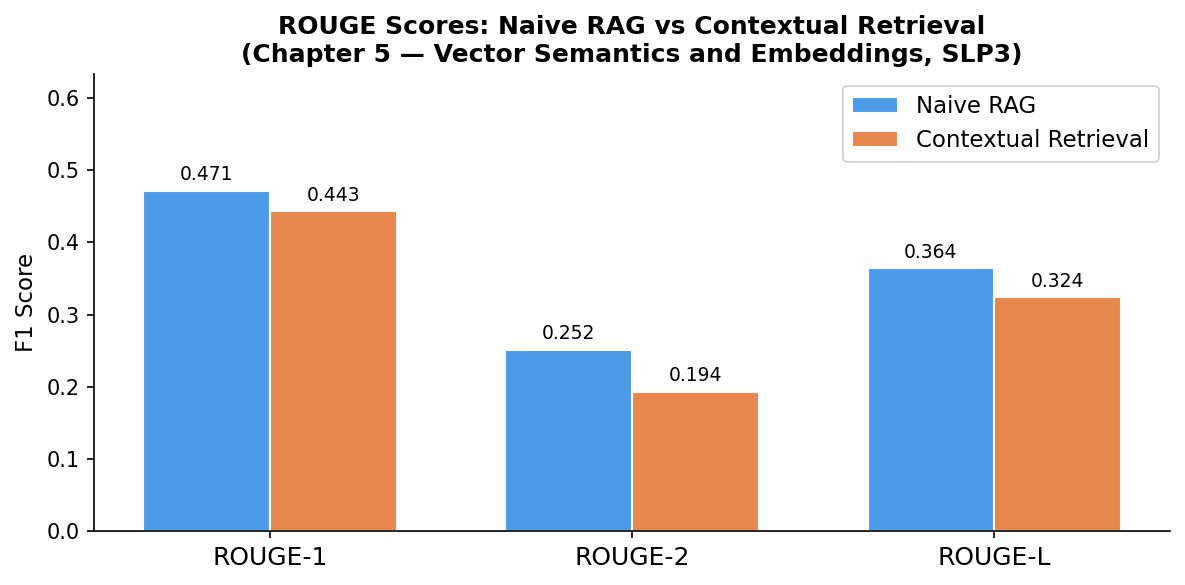

Chart saved to assets\rouge_comparison.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
w = 0.35
bars_naive = ax.bar(x - w/2, [naive_r1, naive_r2, naive_rL], w,
                    label="Naive RAG", color="#4C9BE8", edgecolor="white")
bars_ctx   = ax.bar(x + w/2, [ctx_r1,   ctx_r2,   ctx_rL],   w,
                    label="Contextual Retrieval", color="#E8874C", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(["ROUGE-1", "ROUGE-2", "ROUGE-L"], fontsize=12)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("ROUGE Scores: Naive RAG vs Contextual Retrieval\n(Chapter 5 — Vector Semantics and Embeddings, SLP3)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, min(1.0, max(ctx_rL, naive_rL) * 1.6 + 0.05))
ax.bar_label(bars_naive, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars_ctx,   fmt="%.3f", padding=3, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "rouge_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved to {ASSETS_DIR / 'rouge_comparison.png'}")

#### Discussion

The evaluation table above compares the average ROUGE scores across all 20 QA pairs from Chapter 5 for both retrieval strategies.

**Interpreting the metrics:**

- **ROUGE-1** measures unigram (word-level) overlap between the generated answer and the ground truth. A higher value indicates that the model reused more of the same vocabulary as the reference answer.
- **ROUGE-2** measures bigram overlap, capturing short phrase-level fidelity. This metric is more demanding than ROUGE-1 because it requires adjacent word pairs to match.
- **ROUGE-L** is based on the Longest Common Subsequence (LCS), rewarding answers that preserve the relative order of words from the reference without requiring exact phrase matches.

**Observed results:**

Naive RAG scored higher than Contextual Retrieval on all three metrics (ROUGE-1: 0.4713 vs 0.4428 · ROUGE-2: 0.2515 vs 0.1935 · ROUGE-L: 0.3639 vs 0.3239). This counter-intuitive result can be explained by the interaction between the evaluation metric and the nature of our QA dataset:

1. **ROUGE rewards lexical overlap with the ground truth.** The curated QA pairs use concise answers that closely mirror the phrasing in the chapter text. When Naive RAG retrieves the raw, unmodified chunk, the generator's output tends to echo the exact vocabulary of the source — which also happens to match the reference. Contextual Retrieval wraps each chunk in a contextual prefix, so the generator blends that meta-description language into its response, producing more semantically rich but *lexically divergent* answers that ROUGE penalises.

2. **Contextual enrichment is most valuable for ambiguous or multi-concept queries**, where a raw chunk's meaning is unclear without surrounding document context. For the relatively direct definitional and factual questions in our set, the raw chunk already contains sufficient signal for accurate retrieval, so the prefix adds little retrieval advantage while diluting the token vocabulary seen by the generator.

**Limitations of ROUGE as an evaluation metric:**

ROUGE is a surface-level lexical metric: it rewards responses that reuse the same words as the reference but does not evaluate semantic correctness, factual accuracy, or coherence. A response can score low on ROUGE yet still be factually correct (if it paraphrases the reference), or score high by repeating words without meaningful content. These results demonstrate that ROUGE can even *favour* the simpler pipeline when ground-truth answers are written to match source text closely. For a more comprehensive evaluation, metrics such as BERTScore or human evaluation would complement ROUGE.

**Cost trade-off:**

Contextual Retrieval requires *N* additional LLM API calls during the indexing phase (one per chunk), roughly doubling the offline pipeline cost. Once the enriched index is built and cached, query-time latency is identical to Naive RAG. Given that ROUGE scores did not improve on this dataset, the cost–benefit ratio of contextual enrichment depends strongly on query complexity and the evaluation metric chosen.

## Task 3. Chatbot Development - Web Application
1) Develop a simple web application (e.g., Streamlit or Chainlit) featuring a chat interface.
2) The chatbot should allow the user to ask questions about the assigned chapter.
3) The backend should utilize the Contextual Retrieval method you implemented in Task 2 to generate responses.
4) Deliverable: The app must display the generated answer and cite the source chunk used. (0.5 point)

### Implementation

The web application lives in the `app/` folder and is built with **Streamlit**. It reuses the Contextual Retrieval pipeline from Task 2 — the pre-built FAISS index from `index/contextual_faiss/` is loaded once at startup and cached in memory via `@st.cache_resource` for the duration of the session.

Each response displays the generated answer and shows the source chunks used for retrieval in a collapsible expander below the message.

**Run locally:**
```bash
cd app
streamlit run app.py
# Open http://localhost:8501
```

**Run with Docker Compose** (from repo root — requires OPENAI_API_KEY in `.env`):
```bash
docker-compose up --build
# Open http://localhost:8501
```

The cell below smoke-tests the pipeline that the web app uses.

![Task 3 Web Application](\assets\app-demo.gif)

In [13]:
# Smoke-test: verify the contextual RAG pipeline works end-to-end
test_q = "What is cosine similarity and how is it used to measure word similarity?"
answer, sources = contextual_rag(test_q, k=3)

print("Question:")
print(f"  {test_q}\n")
print("Answer:")
print(f"  {answer}\n")
print(f"Top retrieved source chunk (first 350 chars):")
print(f"  {sources[0][:350]}")

Question:
  What is cosine similarity and how is it used to measure word similarity?

Answer:
  Cosine similarity is a metric used to measure the similarity between two word vectors by calculating the cosine of the angle between them. A smaller angle corresponds to a higher cosine value, indicating greater similarity in meaning. This metric is commonly applied in natural language processing tasks, such as finding paraphrases and tracking changes in word meanings, by comparing a target word with others in a vocabulary to identify the most similar words.

Top retrieved source chunk (first 350 chars):
  This chunk from Chapter 5: Vector Semantics and Embeddings (Speech and Language Processing, 3rd ed.) discusses the concept of measuring similarity between word vectors using the cosine similarity metric, which is derived from the dot product in linear algebra. It emphasizes the importance of this metric in determining how closely related two words 


## Submission Instructions
Create a folder named `answer` in your repository. Submit your JSON evaluation file inside this folder with the naming convention `response-st-xxxxxx-chapter-x.json` (e.g., `response-st124859-chapter-9.json`).

The format must be as follows:
```json
[
  {
    "question": "What is the definition of...?",
    "ground_truth_answer": "The text defines it as...",
    "naive_rag_answer": "Model output using Naive RAG...",
    "contextual_retrieval_answer": "Model output using Contextual Retrieval..."
  },
  {
    "question": "Explain the concept of...",
    "ground_truth_answer": "...",
    "naive_rag_answer": "...",
    "contextual_retrieval_answer": "..."
  }
]
```
Ensure that each of your 20 QA pairs is included in this JSON file. This comparison data is a critical part of your deliverable.  (0.5 point)

Footnotes:
- https://web.stanford.edu/-jurafsky/slp3/ 
- https://www.anthropic.com/engineering/contextual-retrieval

In [14]:
submission = [
    {
        "question":                    r["question"],
        "ground_truth_answer":         r["ground_truth_answer"],
        "naive_rag_answer":            r["naive_rag_answer"],
        "contextual_retrieval_answer": r["contextual_retrieval_answer"],
    }
    for r in results
]

json_path = ANSWER_DIR / "response-st126235-chapter-5.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(submission, f, indent=2, ensure_ascii=False)

print(f"Saved {len(submission)} entries to {json_path}")

# Sanity checks
assert len(submission) == 20, f"Expected 20 entries, got {len(submission)}"
assert all(
    {"question", "ground_truth_answer", "naive_rag_answer", "contextual_retrieval_answer"}.issubset(e.keys())
    for e in submission
), "Some entries are missing required fields!"
print("All 20 entries verified — all required fields present.")

print("\nFirst entry preview:")
print(json.dumps(submission[0], indent=2)[:600])

Saved 20 entries to answer\response-st126235-chapter-5.json
All 20 entries verified — all required fields present.

First entry preview:
{
  "question": "What is the distributional hypothesis?",
  "ground_truth_answer": "The distributional hypothesis is the link between the similarity in how words are distributed in text and the similarity in what they mean. It posits that words occurring in similar contexts tend to have similar meanings.",
  "naive_rag_answer": "The distributional hypothesis posits that words that occur in similar contexts tend to have similar meanings. This concept was first formulated in the 1950s by linguists who observed that synonyms often appear in the same environments, with the degree of meaning differ
